# Notebook 04 - Fine-Tuning with TRL, PEFT, and Optional Unsloth

This chapter explains why TRL and PEFT are required, and where Unsloth is conditionally used.

## Tool Definitions and Why They Matter

### TRL
TRL (Transformer Reinforcement Learning) provides modern supervised fine-tuning trainers (`SFTTrainer`) with LLM-specific conveniences.

### PEFT
PEFT enables parameter-efficient tuning (LoRA/QLoRA), reducing trainable parameters and VRAM demand.

### Unsloth
Unsloth is an optimization framework that can accelerate LoRA/QLoRA training and inference on supported models. In this project it is optional, not forced.

## Official Documentation Review Used Before Implementation (Checked: 2026-06-21)

- TRL official docs (`/huggingface/trl`): validated `SFTTrainer` + `SFTConfig` usage for supervised instruction tuning and QLoRA.
- PEFT official docs (`/huggingface/peft`): validated `prepare_model_for_kbit_training` before `get_peft_model`, and LoRA target module configuration.
- Unsloth official docs (`/unslothai/unsloth`): validated optional backend path using `FastLanguageModel.from_pretrained` and `FastLanguageModel.get_peft_model`.

These references informed the exact order of operations in `src/legal_clause_analyzer/finetune/train.py`.

## What Is This Technique? - QLoRA Fine-Tuning for Legal Structured Generation

### Definition and Core Concepts
QLoRA combines 4-bit quantization with LoRA adapters so we can fine-tune local 3B/4B models on consumer GPUs.

### Why Was This Technique Developed?
Full fine-tuning is expensive and often impractical on local hardware.

### What Limitations of Traditional RAG Does It Solve?
RAG improves context access but does not adapt generation behavior itself. QLoRA teaches the model to emit legal-analysis structure directly.

### Architecture and Workflow Diagram Explanation
```mermaid
flowchart LR
A[Instruction dataset] --> B[TRL SFTTrainer]
B --> C[PEFT LoRA adapters]
C --> D[4-bit quantized base model]
D --> E[Fine-tuned legal analyzer adapter]
```

If Unsloth is installed and compatible, model loading/adapter wiring uses Unsloth APIs first; otherwise the pipeline falls back to TRL+PEFT.

### Component-by-Component Breakdown
1. Quantized model loading.
2. LoRA configuration and adapter attachment.
3. TRL SFT trainer loop.
4. Backend auto-selection (Unsloth or TRL+PEFT).
5. Runtime artifact logging for memory and backend choice.

### When Should It Be Used in Real-World Systems?
Use for domain-specific behavior adaptation when prompt engineering alone is insufficient.

### Advantages and Disadvantages
Advantages:
- Works on single local GPU.
- Faster iteration than full fine-tuning.
- Better schema consistency.

Disadvantages:
- Adapter quality depends on supervision quality.
- Small models still have reasoning limits.
- Backend compatibility varies by model/runtime.

### Comparison Against Standard RAG and Other Implemented Variants
Compared to standard RAG, QLoRA changes model behavior persistently. Compared to prompt-only baselines, it requires training time but yields more stable structured outputs.

### Implementation Details and Design Decisions Used in This Project
This project uses TRL `SFTTrainer`, PEFT `prepare_model_for_kbit_training` + `LoraConfig`, and optional Unsloth `FastLanguageModel` when available.


In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
ROOT = next((p for p in candidates if (p / 'scripts').exists() and (p / 'configs').exists()), cwd)
print('Project root:', ROOT)

def run_py(script: str, *args: str) -> None:
    cmd = [sys.executable, str(ROOT / script), *args]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=str(ROOT))


Project root: /home/ahmad/AI/Legal-Document-Summarizer-Clause-Analyzer


In [2]:
metrics_path = ROOT / 'artifacts/models/finetuned_adapter/training_metrics.json'
if not metrics_path.exists():
    run_py('scripts/train_model.py', '--config', 'configs/default.yaml')
train_metrics = json.loads(metrics_path.read_text())
train_metrics

{'train': {'train_runtime': 103.3201,
  'train_samples_per_second': 0.619,
  'train_steps_per_second': 0.077,
  'total_flos': 982373513963520.0,
  'train_loss': 1.9849695563316345,
  'epoch': 0.04155844155844156},
 'eval': {'eval_loss': 1.8864628076553345,
  'eval_runtime': 33.702,
  'eval_samples_per_second': 2.878,
  'eval_steps_per_second': 2.878,
  'eval_entropy': 1.761440034994145,
  'eval_mean_token_accuracy': 0.6126565816476173,
  'eval_num_tokens': 51958.0,
  'epoch': 0.04155844155844156},
 'model_name': 'ibm-granite/granite-4.1-3b',
 'training_backend': 'trl_peft',
 'quantized_4bit': True,
 'train_rows': 1540,
 'validation_rows': 97}

In [3]:
backend_report_path = ROOT / 'artifacts/models/finetuned_adapter/training_backend_report.json'
backend_report = json.loads(backend_report_path.read_text())
backend_report

{'backend_order': ['unsloth', 'trl'],
 'selected_backend': 'trl_peft',
 'selected_model': 'ibm-granite/granite-4.1-3b',
 'attempts': [{'backend': 'unsloth',
   'model': 'ibm-granite/granite-4.1-3b',
   'error': 'Unsloth is not installed in this environment.'},
  {'backend': 'unsloth',
   'model': 'Qwen/Qwen3.5-4B',
   'error': 'Unsloth is not installed in this environment.'}]}

In [4]:
runtime_path = ROOT / 'artifacts/metrics/training_runtime_report.json'
runtime_report = json.loads(runtime_path.read_text()) if runtime_path.exists() else {}
selected_backend = backend_report.get('selected_backend', 'unknown')
tool_coverage = pd.DataFrame([
    {
        'tool': 'TRL',
        'definition': 'Trainer framework for LLM fine-tuning (SFTTrainer).',
        'why_used': 'Needed a robust supervised fine-tuning loop and logging.',
        'where_used': 'finetune/train.py::_build_sft_config + _build_trainer',
        'what_changed': 'Unified training config and checkpoint/eval behavior.',
        'observed_effect': 'Training artifacts (loss curves, metrics) produced consistently.',
    },
    {
        'tool': 'PEFT',
        'definition': 'Parameter-efficient adaptation via LoRA/QLoRA adapters.',
        'why_used': 'Full fine-tuning was too heavy for local 8GB-class GPUs.',
        'where_used': 'prepare_model_for_kbit_training + get_peft_model in finetune/train.py',
        'what_changed': 'Only adapter parameters are trained.',
        'observed_effect': 'Fine-tuned adapter artifacts and measurable metric deltas vs baselines.',
    },
    {
        'tool': 'Unsloth',
        'definition': 'Optional accelerated LoRA/QLoRA backend on supported models.',
        'why_used': 'Potential speed/VRAM benefit where compatible.',
        'where_used': 'finetune/train.py::_load_unsloth_bundle (auto-first fallback path)',
        'what_changed': f"Runtime backend order = {backend_report.get('backend_order', [])}",
        'observed_effect': f"Selected backend in this run = {selected_backend}",
    },
])
tool_coverage

,tool,definition,why_used,where_used,what_changed,observed_effect
0,TRL,Trainer framework for LLM fine-tuning (SFTTrai...,Needed a robust supervised fine-tuning loop an...,finetune/train.py::_build_sft_config + _build_...,Unified training config and checkpoint/eval be...,"Training artifacts (loss curves, metrics) prod..."
1,PEFT,Parameter-efficient adaptation via LoRA/QLoRA ...,Full fine-tuning was too heavy for local 8GB-c...,prepare_model_for_kbit_training + get_peft_mod...,Only adapter parameters are trained.,Fine-tuned adapter artifacts and measurable me...
2,Unsloth,Optional accelerated LoRA/QLoRA backend on sup...,Potential speed/VRAM benefit where compatible.,finetune/train.py::_load_unsloth_bundle (auto-...,"Runtime backend order = ['unsloth', 'trl']",Selected backend in this run = trl_peft


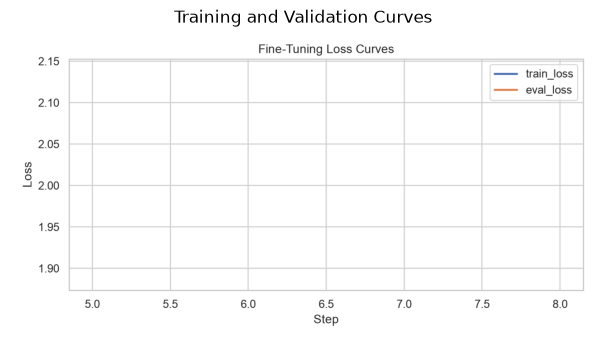

In [5]:
curve_png = ROOT / 'artifacts/figures/training_curve.png'
img = plt.imread(curve_png)
plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Training and Validation Curves')
plt.show()

## What Changed Because of TRL, PEFT, and Unsloth?

1. **TRL** changed the project from ad-hoc loops to a reproducible SFT pipeline with consistent training/eval/checkpoint artifacts.
2. **PEFT** changed the optimization target from full-model updates to adapter-only updates, enabling QLoRA on local hardware budgets.
3. **Unsloth** changed backend selection strategy: it is attempted first only when available and useful, then cleanly falls back to TRL+PEFT.

Use the `tool_coverage` table and backend/runtime artifacts above to connect tool choice to observed post-run behavior in your environment.